#### Simulations Parameter 

In [1]:
#Libarys
from utils import simulation, save_results, plot_pred_bias, plot_var_bias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import json

In [2]:
# Sim settings
train_models= True
ijk_wager_calc= True
ijk_butt_calc= True
ijk_jahn_calc= True
jk_wager_calc= True
boot_calc= [False, 0 ]


In [3]:
n_sim = 1000
n = int(1000.5/0.7)
B_RF = int(n * 0.7 )

X_pred_point = pd.DataFrame({'X_1': [0], 'X_2': [1], 'X_3': [80], 'X_4': [40]})
seed = 42
n_covariates = 4

In [4]:
# data generation parameters and RF parameters
data_generation_parameter_1 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':   22_080       , 
                                    'rate_censoring':       0.00321    , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point}  

data_generation_parameter_3 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':  18_900        , 
                                    'rate_censoring':       0.01125   , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point }

data_generation_parameter_5 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':  15120        , 
                                    'rate_censoring':       0.023293   , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point }


params_rf =         {   'n_estimators':B_RF,                        
                        'max_depth':4,
                        'min_samples_split':5,
                        'max_features': 'log2',
                        'random_state':  seed,
                        'weighted_bootstrapping': True, }

#### Start Simulation

In [5]:
# Run simulations
dp = data_generation_parameter_1
with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk_u_butt_var = np.zeros(n_sim)
    ijk_u2_butt_var = np.zeros(n_sim)
    ijk_jahn_var = np.zeros(n_sim)
    ijk_u_jahn_var = np.zeros(n_sim)
    ijk_u2_jahn_var = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_u_wager_var = np.zeros(n_sim)
    jk_wager_var = np.zeros(n_sim)
    jk_u_wager_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)

    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)

    futures = [ executor.submit(  
                                  simulation,
                                  seed=seed+i,
                                  data_generation_parameter=dp,
                                  params_rf=params_rf,
                                  train_models=train_models,
                                  ijk_wager_calc=ijk_wager_calc,
                                  ijk_butt_calc=ijk_butt_calc,
                                  ijk_jahn_calc=ijk_jahn_calc,
                                  jk_wager_calc=jk_wager_calc,
                                  boot_calc=boot_calc,)
                for i in range(n_sim) ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_butt_var, _ijk_jahn_var, _ijk_wager_var, _jk_wager_var, _boot_var, _survived_stats_train,_survived_stats_test   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

        #Evaluation Results
        wb_test_mse[i] = _wb_test_mse
        rf_test_mse[i] = _rf_test_mse

        #Prediction Results
        wb_pred[i] = _wb_pred[0]
        rf_pred[i] = _rf_pred[0]

        # Standard Deviation Estimates
        ijk_butt_var[i] = _ijk_butt_var[0]
        ijk_u_butt_var[i] = _ijk_butt_var[0] - _ijk_butt_var[1]
        ijk_u2_butt_var[i] = _ijk_butt_var[0] - _ijk_butt_var[2]

        ijk_jahn_var[i] = _ijk_jahn_var[0]
        ijk_u_jahn_var[i] = _ijk_jahn_var[0] - _ijk_jahn_var[1]
        ijk_u2_jahn_var[i] = _ijk_jahn_var[0] - _ijk_jahn_var[2]

        ijk_wager_var[i] = _ijk_wager_var[0]
        ijk_u_wager_var[i] = _ijk_wager_var[0] - _ijk_wager_var[1]

        jk_wager_var[i] = _jk_wager_var[0]
        jk_u_wager_var[i] = _jk_wager_var[0] - _jk_wager_var[1]

        boot_var[i] = _boot_var

results1 = pd.DataFrame({'portion_zero_weights_train': portion_zero_weights_train, 'portion_seen_events_train': portion_seen_events_train,
                        'portion_zero_weights_test': portion_zero_weights_test, 'portion_seen_events_test': portion_seen_events_test,
                        'wb_test_mse': wb_test_mse, 'rf_test_mse': rf_test_mse, 'wb_pred': wb_pred, 'rf_pred': rf_pred, 
                        'ijk_butt_var': ijk_butt_var, 'ijk_u_butt_var': ijk_u_butt_var, 'ijk_u2_butt_var': ijk_u2_butt_var,
                        'ijk_jahn_var': ijk_jahn_var, 'ijk_u_jahn_var': ijk_u_jahn_var, 'ijk_u2_jahn_var': ijk_u2_jahn_var,
                        'ijk_wager_var': ijk_wager_var, 'ijk_u_wager_var': ijk_u_wager_var, 'jk_wager_var': jk_wager_var, 'jk_u_wager_var': jk_u_wager_var,
                        'boot_var': boot_var, 
                        })


dp = data_generation_parameter_3
with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk_u_butt_var = np.zeros(n_sim)
    ijk_u2_butt_var = np.zeros(n_sim)
    ijk_jahn_var = np.zeros(n_sim)
    ijk_u_jahn_var = np.zeros(n_sim)
    ijk_u2_jahn_var = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_u_wager_var = np.zeros(n_sim)
    jk_wager_var = np.zeros(n_sim)
    jk_u_wager_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)

    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)

    futures = [ executor.submit(  
                                  simulation,
                                  seed=seed+i,
                                  data_generation_parameter=dp,
                                  params_rf=params_rf,
                                  train_models=train_models,
                                  ijk_wager_calc=ijk_wager_calc,
                                  ijk_butt_calc=ijk_butt_calc,
                                  ijk_jahn_calc=ijk_jahn_calc,
                                  jk_wager_calc=jk_wager_calc,
                                  boot_calc=boot_calc,)
                for i in range(n_sim) ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_butt_var, _ijk_jahn_var, _ijk_wager_var, _jk_wager_var, _boot_var, _survived_stats_train,_survived_stats_test   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

        #Evaluation Results
        wb_test_mse[i] = _wb_test_mse
        rf_test_mse[i] = _rf_test_mse

        #Prediction Results
        wb_pred[i] = _wb_pred[0]
        rf_pred[i] = _rf_pred[0]

        # Standard Deviation Estimates
        ijk_butt_var[i] = _ijk_butt_var[0]
        ijk_u_butt_var[i] = _ijk_butt_var[0] - _ijk_butt_var[1]
        ijk_u2_butt_var[i] = _ijk_butt_var[0] - _ijk_butt_var[2]

        ijk_jahn_var[i] = _ijk_jahn_var[0]
        ijk_u_jahn_var[i] = _ijk_jahn_var[0] - _ijk_jahn_var[1]
        ijk_u2_jahn_var[i] = _ijk_jahn_var[0] - _ijk_jahn_var[2]

        ijk_wager_var[i] = _ijk_wager_var[0]
        ijk_u_wager_var[i] = _ijk_wager_var[0] - _ijk_wager_var[1]

        jk_wager_var[i] = _jk_wager_var[0]
        jk_u_wager_var[i] = _jk_wager_var[0] - _jk_wager_var[1]

        boot_var[i] = _boot_var

results3 = pd.DataFrame({'portion_zero_weights_train': portion_zero_weights_train, 'portion_seen_events_train': portion_seen_events_train,
                        'portion_zero_weights_test': portion_zero_weights_test, 'portion_seen_events_test': portion_seen_events_test,
                        'wb_test_mse': wb_test_mse, 'rf_test_mse': rf_test_mse, 'wb_pred': wb_pred, 'rf_pred': rf_pred, 
                        'ijk_butt_var': ijk_butt_var, 'ijk_u_butt_var': ijk_u_butt_var, 'ijk_u2_butt_var': ijk_u2_butt_var,
                        'ijk_jahn_var': ijk_jahn_var, 'ijk_u_jahn_var': ijk_u_jahn_var, 'ijk_u2_jahn_var': ijk_u2_jahn_var,
                        'ijk_wager_var': ijk_wager_var, 'ijk_u_wager_var': ijk_u_wager_var, 'jk_wager_var': jk_wager_var, 'jk_u_wager_var': jk_u_wager_var,
                        'boot_var': boot_var, 
                        })


dp = data_generation_parameter_5
with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk_u_butt_var = np.zeros(n_sim)
    ijk_u2_butt_var = np.zeros(n_sim)
    ijk_jahn_var = np.zeros(n_sim)
    ijk_u_jahn_var = np.zeros(n_sim)
    ijk_u2_jahn_var = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_u_wager_var = np.zeros(n_sim)
    jk_wager_var = np.zeros(n_sim)
    jk_u_wager_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)

    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)

    futures = [ executor.submit(  
                                  simulation,
                                  seed=seed+i,
                                  data_generation_parameter=dp,
                                  params_rf=params_rf,
                                  train_models=train_models,
                                  ijk_wager_calc=ijk_wager_calc,
                                  ijk_butt_calc=ijk_butt_calc,
                                  ijk_jahn_calc=ijk_jahn_calc,
                                  jk_wager_calc=jk_wager_calc,
                                  boot_calc=boot_calc,)
                for i in range(n_sim) ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_butt_var, _ijk_jahn_var, _ijk_wager_var, _jk_wager_var, _boot_var, _survived_stats_train,_survived_stats_test   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

        #Evaluation Results
        wb_test_mse[i] = _wb_test_mse
        rf_test_mse[i] = _rf_test_mse

        #Prediction Results
        wb_pred[i] = _wb_pred[0]
        rf_pred[i] = _rf_pred[0]

        # Standard Deviation Estimates
        ijk_butt_var[i] = _ijk_butt_var[0]
        ijk_u_butt_var[i] = _ijk_butt_var[0] - _ijk_butt_var[1]
        ijk_u2_butt_var[i] = _ijk_butt_var[0] - _ijk_butt_var[2]

        ijk_jahn_var[i] = _ijk_jahn_var[0]
        ijk_u_jahn_var[i] = _ijk_jahn_var[0] - _ijk_jahn_var[1]
        ijk_u2_jahn_var[i] = _ijk_jahn_var[0] - _ijk_jahn_var[2]

        ijk_wager_var[i] = _ijk_wager_var[0]
        ijk_u_wager_var[i] = _ijk_wager_var[0] - _ijk_wager_var[1]

        jk_wager_var[i] = _jk_wager_var[0]
        jk_u_wager_var[i] = _jk_wager_var[0] - _jk_wager_var[1]

        boot_var[i] = _boot_var

results5 = pd.DataFrame({'portion_zero_weights_train': portion_zero_weights_train, 'portion_seen_events_train': portion_seen_events_train,
                        'portion_zero_weights_test': portion_zero_weights_test, 'portion_seen_events_test': portion_seen_events_test,
                        'wb_test_mse': wb_test_mse, 'rf_test_mse': rf_test_mse, 'wb_pred': wb_pred, 'rf_pred': rf_pred, 
                        'ijk_butt_var': ijk_butt_var, 'ijk_u_butt_var': ijk_u_butt_var, 'ijk_u2_butt_var': ijk_u2_butt_var,
                        'ijk_jahn_var': ijk_jahn_var, 'ijk_u_jahn_var': ijk_u_jahn_var, 'ijk_u2_jahn_var': ijk_u2_jahn_var,
                        'ijk_wager_var': ijk_wager_var, 'ijk_u_wager_var': ijk_u_wager_var, 'jk_wager_var': jk_wager_var, 'jk_u_wager_var': jk_u_wager_var,
                        'boot_var': boot_var, 
                        })

exp_save_path = save_results(n=n, n_covariates=n_covariates, B_RF=B_RF, boot_calc=boot_calc, seed=seed, results1=results1, results3=results3, results5=results5,
             data_generation_parameter_1=data_generation_parameter_1, data_generation_parameter_3=data_generation_parameter_3, 
             data_generation_parameter_5=data_generation_parameter_5, params_rf=params_rf)

Simulations: 100%|██████████| 1000/1000 [03:28<00:00,  4.79simulation/s]


#### Plots

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


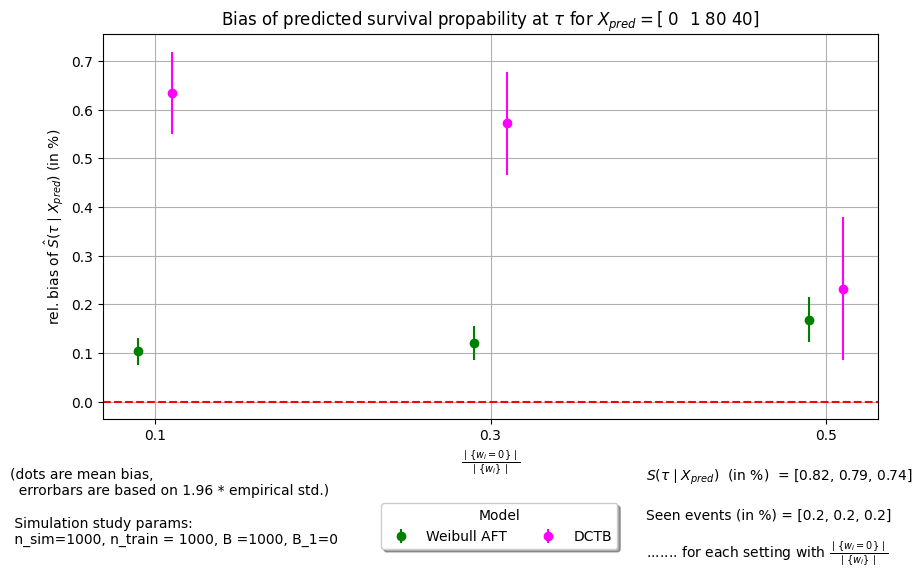

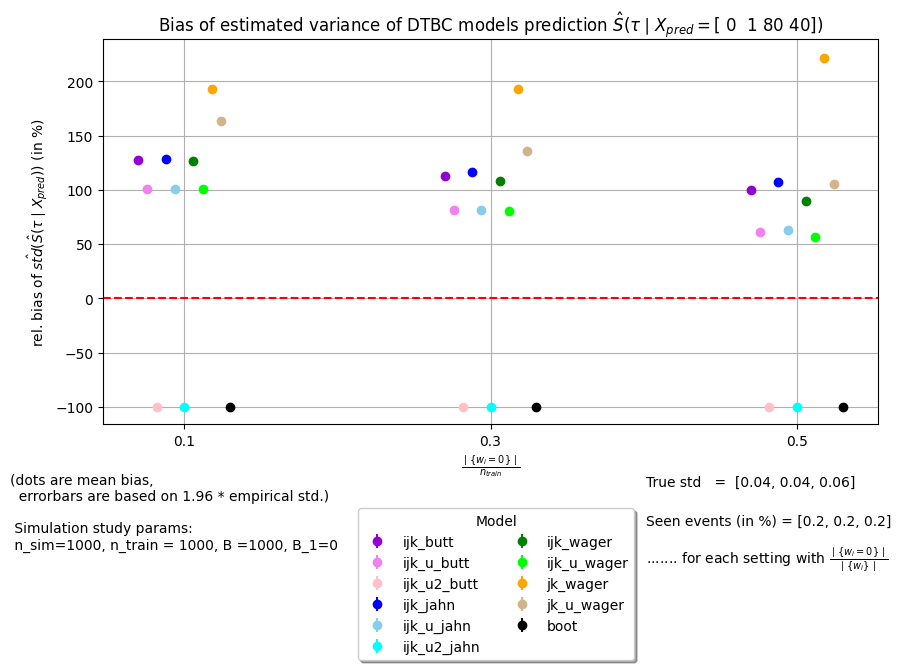

In [6]:
#exp_save_path2 = r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper\results\(n_train)1000__(B_RF)1000__(B_1)0__(n_sim)1000__(seed)42__3kovariates\121.899958'
plot_pred_bias(exp_save_path)
plot_var_bias(exp_save_path)

In [7]:
# with open(exp_save_path + '/setting.json') as f:
#     exp_settings = json.load(f)

# # lade results
# results1 = pd.read_csv(exp_save_path + f"/results1__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][0]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][0]}.csv")
# results3 = pd.read_csv(exp_save_path + f"/results3__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][1]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][1]}.csv")
# results5 = pd.read_csv(exp_save_path + f"/results5__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][2]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][2]}.csv")

# # True Standard Deviations
# true_std_1  = results1['rf_pred'].std(ddof=1) 
# true_std_3  = results3['rf_pred'].std(ddof=1) 
# true_std_5  = results5['rf_pred'].std(ddof=1) 

# # Bias and Error of the Standard Deviation Estimates
# var_bias_1 = [ (np.mean(results1['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-     true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-   true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['ijk_u2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-  true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['ijk_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-     true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-   true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['ijk_u2_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-  true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-    true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-  true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['jk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-     true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['jk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-   true_std_1)/true_std_1 * 100  ,
#                (np.mean(results1['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-         true_std_1)/true_std_1 * 100  ,   ]

# var_bias_3 = [ (np.mean(results3['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-     true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-   true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['ijk_u2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-  true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['ijk_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-     true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-   true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['ijk_u2_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-  true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-    true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-  true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['jk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-     true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['jk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-   true_std_3)/true_std_3 * 100  ,
#                (np.mean(results3['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-         true_std_3)/true_std_3 * 100  ,   ]

# var_bias_5 = [ (np.mean(results5['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-     true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-   true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['ijk_u2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-  true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['ijk_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-     true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-   true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['ijk_u2_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-  true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-    true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-  true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['jk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-     true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['jk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-   true_std_5)/true_std_5 * 100  ,
#                (np.mean(results5['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))-         true_std_5)/true_std_5 * 100  ,   ]

# var_error_1 =[ np.std(  (results1['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -   true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  - true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['ijk_u2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['ijk_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) -    true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  - true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['ijk_u2_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-  true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -  true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-  true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['jk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -   true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['jk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  - true_std_1) /true_std_1 , ddof=1 )  ,
#                np.std(  (results1['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -       true_std_1) /true_std_1 , ddof=1 )  ,  ]

# var_error_3 =[ np.std(  (results3['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -   true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  - true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['ijk_u2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['ijk_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) -    true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  - true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['ijk_u2_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-  true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -  true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['jk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -   true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['jk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  - true_std_3) /true_std_3 , ddof=1 )  ,
#                np.std(  (results3['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -       true_std_3) /true_std_3 , ddof=1 )  ,  ]

# var_error_5 =[ np.std(  (results5['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -   true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  - true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['ijk_u2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['ijk_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) -    true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  - true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['ijk_u2_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-  true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -  true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['jk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -   true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['jk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  - true_std_5) /true_std_5 , ddof=1 )  ,
#                np.std(  (results5['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)  -       true_std_5) /true_std_5 , ddof=1 )  ,  ]

# var_bias =  [ var_bias_1,   var_bias_3,   var_bias_5  ]
# errors =    [ var_error_1, var_error_3, var_error_5 ]

# names = [_[:-4] for _ in results1.columns[9:]] # names of the methods
# weights_zero = [ round(_, 2) for _ in exp_settings['portion_zero_weights_train[1,3,5]']]

# # Erzeuge ein Plot
# plt.figure(figsize=(10, 5))
# colors = [
#     'darkviolet', 'violet', 'pink',  # Ähnliche Farben 1
#     'blue', 'skyblue', 'cyan',       # Ähnliche Farben 2
#     'green', 'lime',                 # Ähnliche Farben 3
#     'orange', 'tan',  
#     'black'         ]

# # Plotten der Punkte mit Fehlerbalken und Legende
# offset = np.linspace(-0.03, 0.03, len(names))  # Kleinere Versatzwerte für die x-Werte
# for j, name in enumerate(names):
#     for i, weight in enumerate(weights_zero):
#         plt.errorbar(weight + offset[j], var_bias[i][j], yerr=errors[i][j], fmt='o', color=colors[j], label=name if i == 0 else "")

# # Achsenbeschriftungen und Titel hinzufügen
# plt.axhline(y=0, color='red', linestyle='--')
# plt.title('Variance Prediction Bias')
# plt.grid(True)
# plt.xticks(weights_zero)
# plt.xlabel(r'$\frac{\mid \{w_i=0\} \mid}{n_{train}}$')
# plt.ylabel(r'rel. bias of $\hat{std}( \hat{S}(\tau\mid X_{pred}))$')
# plt.title(r'Bias of estimated variance of DTBC models prediction $\hat{S}(\tau\mid X_{pred}=$'+str(exp_settings['X_pred_point'])+str(')'))
# plt.legend(title='Model', loc='upper left', fancybox=True, shadow=True, ncol=2, bbox_to_anchor=(0.32, -0.2))
# a = 0.7
# b= -0.15
# plt.text(-0.12, -0.25, f"(dots are mean bias,\n  errorbars are based on 1.96 * empirical std.)\n\n Simulation study params: \n n_sim={exp_settings['n_sim']}, n_train = {exp_settings['n_train'] }, B ={exp_settings['B_RF']}, B_1={exp_settings['B_1'] }\n ", 
#         ha='left', va='center', transform=plt.gca().transAxes)
# plt.text(a,b, r"True std   = "+ f" {[ round(_, 2) for _ in [true_std_1, true_std_3, true_std_5]]}" ,
#         ha='left', va='center', transform=plt.gca().transAxes)
# plt.text(a,b-0.1, f"Seen events (in %) = {[round(_,2) for _ in exp_settings['portion_seen_events_train[1,3,5]']]} ",
#         ha='left', va='center', transform=plt.gca().transAxes)
# plt.text(a,b-0.2, r"....... for each setting with $\frac{\mid \{w_i=0\} \mid}{\mid \{w_i\} \mid}$", 
#         ha='left', va='center', transform=plt.gca().transAxes) 
# plt.savefig(exp_save_path + f'/pred_var_bias(n_train){exp_settings["n_train"]}__(B_RF){exp_settings["B_RF"]}__(n_sim){exp_settings["n_sim"]}__covariates{exp_settings["n_covariates"]}.png', bbox_inches='tight')